### **Aprendizaje contrastivo, *zero-shot* y recuperación imagen-texto con OpenCLIP**

Este cuaderno corresponde al laboratorio reproducible de la Semana 5 del curso **MCC225 - IA Generativa y Aprendizaje Multimodal**. El objetivo no es solamente ejecutar un modelo, sino producir evidencia experimental defendible: escala razonable del subconjunto, rutas canónicas, registro del entorno, métricas de ranking, análisis de errores, visualizaciones y un reporte interpretativo.

Al finalizar, el estudiante debe poder construir *embeddings* multimodales, evaluar recuperación imagen->texto y texto->imagen, comparar plantillas de *prompting* para *zero-shot*, visualizar resultados *top-k*, construir una matriz de confusión, comparar *checkpoints* abiertos y distinguir entre resultados concluyentes, demostrativos y extensiones exploratorias.


#### **0. Alcance, rutas canónicas y criterio de validez**

El cuaderno debe ejecutarse desde la raíz del proyecto, es decir, desde el directorio que contiene `src/`, `scripts/`, `data/`, `configs/`, `outputs/` y `reports/`. Para evitar inconsistencias entre rutas como `/workspace/Semana5` y `/workspace/Proyecto`, todas las rutas se derivan automáticamente de `PROJECT_ROOT`.

La evaluación principal de recuperación debe usar entre **100 y 500 imágenes**. Por defecto se usan **300 imágenes** de Flickr30k. El subconjunto bootstrap de 6 imágenes queda como respaldo operativo y como microdemostración etiquetada de *zero-shot* cuando el subconjunto ampliado no posee etiquetas cerradas.

**Nota metodológica.** Flickr30k es un dataset natural para recuperación imagen-texto, no necesariamente para clasificación cerrada. Por tanto, la sección *zero-shot* solo es experimentalmente principal si existe una columna `label` no vacía y compatible con `prompt_config.json`. Si no existe, el cuaderno marca esa evaluación como demostrativa.


In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="open_clip.*"
)

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="torch.*"
)

In [2]:
from pathlib import Path
import sys
import os
import json
import time
import shutil
import platform
import subprocess
import importlib
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if all((candidate / name).exists() for name in ['src', 'scripts', 'data']):
            return candidate
    raise RuntimeError('Ejecute el cuaderno desde la raíz del proyecto: debe contener src/, scripts/ y data/.')


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset_utils import load_metadata, build_caption_targets
from src.openclip_utils import create_model, encode_texts
from src.metrics import compute_similarity_matrix, summarize_multi_target_ranking
from src.retrieval import topk_text_to_image, topk_image_to_text
from src.visualize import show_gallery

PATHS = {
    'data': PROJECT_ROOT / 'data',
    'scripts': PROJECT_ROOT / 'scripts',
    'configs': PROJECT_ROOT / 'configs',
    'outputs': PROJECT_ROOT / 'outputs',
    'reports': PROJECT_ROOT / 'reports',
    'metadata': PROJECT_ROOT / 'outputs' / 'metadata',
    'metrics': PROJECT_ROOT / 'outputs' / 'metrics',
    'embeddings': PROJECT_ROOT / 'outputs' / 'embeddings',
    'figures': PROJECT_ROOT / 'outputs' / 'figures',
    'tests': PROJECT_ROOT / 'tests',
}
for path in PATHS.values():
    path.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'ViT-B-32'
PRETRAINED = 'laion2b_s34b_b79k'
TARGET_N_IMAGES = 300       # rango recomendado: 100 a 500
BATCH_SIZE = 32
RANDOM_STATE = 42

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'Modelo base = {MODEL_NAME} / {PRETRAINED}')
print(f'Tamaño objetivo del subconjunto = {TARGET_N_IMAGES} imágenes')


PROJECT_ROOT = /workspace/Semana5/Proyecto
Modelo base = ViT-B-32 / laion2b_s34b_b79k
Tamaño objetivo del subconjunto = 300 imágenes


#### **0.1 Limpieza controlada de *checkpoints* y archivos temporales**

Esta celda elimina artefactos generados automáticamente por Jupyter o Python: `.ipynb_checkpoints`, `__pycache__` y archivos `.pyc`. No elimina datos, métricas, reportes ni *embeddings*. La finalidad es entregar un repositorio limpio y auditable.


In [3]:
CLEAN_TEMPORARY_ARTIFACTS = True
removed = []

if CLEAN_TEMPORARY_ARTIFACTS:
    for directory_name in ['.ipynb_checkpoints', '__pycache__']:
        for directory in PROJECT_ROOT.rglob(directory_name):
            if directory.is_dir():
                shutil.rmtree(directory, ignore_errors=True)
                removed.append(str(directory.relative_to(PROJECT_ROOT)))
    for pyc in PROJECT_ROOT.rglob('*.pyc'):
        try:
            pyc.unlink()
            removed.append(str(pyc.relative_to(PROJECT_ROOT)))
        except FileNotFoundError:
            pass

print(f'Artefactos temporales eliminados: {len(removed)}')
for item in removed[:25]:
    print(' -', item)
if len(removed) > 25:
    print(f' ... {len(removed) - 25} adicionales')


Artefactos temporales eliminados: 1
 - .ipynb_checkpoints


#### **0.2 Registro del entorno de ejecución**

Todo resultado debe quedar acompañado de un registro mínimo: fecha, sistema operativo, versión de Python, PyTorch, CUDA, GPU, OpenCLIP y *checkpoint*. Este registro explica diferencias de reproducibilidad entre Docker local, Colab, Kaggle o SLURM.


In [4]:
def safe_module_version(module_name):
    try:
        module = importlib.import_module(module_name)
        return str(getattr(module, '__version__', 'version_not_exposed'))
    except Exception as exc:
        return f'unavailable: {type(exc).__name__}'


def git_revision(root):
    try:
        result = subprocess.run(['git', 'rev-parse', '--short', 'HEAD'], cwd=root, capture_output=True, text=True, check=True)
        return result.stdout.strip()
    except Exception:
        return 'not_available'


def torch_environment():
    record = {'torch_version': safe_module_version('torch'), 'cuda_available': False, 'cuda_version': None, 'gpu_name': None, 'gpu_count': 0}
    try:
        import torch
        record['cuda_available'] = bool(torch.cuda.is_available())
        record['cuda_version'] = getattr(torch.version, 'cuda', None)
        record['gpu_count'] = int(torch.cuda.device_count()) if torch.cuda.is_available() else 0
        if torch.cuda.is_available() and record['gpu_count'] > 0:
            record['gpu_name'] = torch.cuda.get_device_name(0)
    except Exception as exc:
        record['torch_error'] = repr(exc)
    return record


environment_record = {
    'timestamp_utc': datetime.now(timezone.utc).isoformat(),
    'project_root': str(PROJECT_ROOT),
    'git_revision': git_revision(PROJECT_ROOT),
    'python': sys.version.replace('\n', ' '),
    'platform': platform.platform(),
    'numpy_version': np.__version__,
    'pandas_version': pd.__version__,
    'open_clip_version': safe_module_version('open_clip'),
    'model_name': MODEL_NAME,
    'pretrained_checkpoint': PRETRAINED,
    'target_n_images': TARGET_N_IMAGES,
    **torch_environment(),
}

environment_path = PATHS['metadata'] / 'environment_record.json'
environment_path.write_text(json.dumps(environment_record, indent=2, ensure_ascii=False), encoding='utf-8')
display(pd.DataFrame([environment_record]).T.rename(columns={0: 'valor'}))
print(f'Registro guardado en: {environment_path.relative_to(PROJECT_ROOT)}')


,valor
timestamp_utc,2026-04-30T23:32:24.642407+00:00
project_root,/workspace/Semana5/Proyecto
git_revision,3d74466
python,"3.11.15 (main, Mar 16 2026, 23:07:56) [GCC 14...."
platform,Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-...
numpy_version,1.26.4
pandas_version,2.2.2
open_clip_version,2.26.1
model_name,ViT-B-32
pretrained_checkpoint,laion2b_s34b_b79k


Registro guardado en: outputs/metadata/environment_record.json


#### **1. Dataset ampliado y control de validez**

Este bloque prepara un subconjunto ampliado entre **100 y 500 imágenes**. La configuración recomendada para clase es `TARGET_N_IMAGES = 300`, porque permite métricas menos triviales sin convertir el laboratorio en una práctica de infraestructura.

Para evitar el fallo observado con `nlphuji/flickr30k` y su cargador legado, el cuaderno usa por defecto `Vishva007/Flickr-Dataset-1k`, un subconjunto en formato Parquet de Flickr30k. Este backend es más liviano y evita descargar el ZIP completo de imágenes. Si no hay conexión o falla Hugging Face, el cuaderno cae al subconjunto bootstrap y lo declara explícitamente como respaldo funcional, no como evidencia experimental fuerte.


In [5]:
def is_non_scalar_container(x):
    """Identifica contenedores que no deben convertirse a texto durante la limpieza visual."""
    return isinstance(x, (list, tuple, dict, set))


def is_missing_value(x):
    """Detecta valores vacíos que no deben mostrarse como texto en tablas o figuras."""
    if x is None:
        return True
    if is_non_scalar_container(x):
        return False
    try:
        value = pd.isna(x)
        if isinstance(value, (bool, np.bool_)) and value:
            return True
    except Exception:
        pass
    text = str(x).strip()
    return text == "" or text.lower() in {"nan", "none", "null", "<na>", "nat"}


def clean_text(x, fallback=""):
    """Convierte un valor escalar a texto seguro para visualización."""
    if is_missing_value(x):
        return fallback
    return str(x).strip()


def clean_scalar_or_preserve_container(x, fallback=""):
    """Limpia escalares, pero preserva listas/diccionarios usados por el pipeline."""
    if is_non_scalar_container(x):
        return x
    return clean_text(x, fallback=fallback)


def normalize_caption_list(value, fallback_caption=""):
    """Normaliza captions a lista de strings sin convertir la lista completa en texto.

    Este punto es crítico: `all_captions` debe seguir siendo una lista. Si se convierte
    accidentalmente en string, `build_caption_targets` la recorre carácter por carácter y
    aparecen miles de captions falsas.
    """
    captions = []

    if isinstance(value, str):
        text = value.strip()
        if text:
            try:
                parsed = json.loads(text)
                value = parsed
            except Exception:
                value = [text]
        else:
            value = []

    if isinstance(value, dict):
        captions = list(value.values())
    elif isinstance(value, (list, tuple, set)):
        captions = list(value)
    elif value is None or is_missing_value(value):
        captions = []
    else:
        captions = [value]

    cleaned = [clean_text(c, fallback="") for c in captions]
    cleaned = [c for c in cleaned if c]
    fallback = clean_text(fallback_caption, fallback="")
    return cleaned or ([fallback] if fallback else [])


def shorten_text(x, max_chars=90, fallback="sin descripción"):
    """Acorta captions largas sin introducir valores vacíos en títulos."""
    text = clean_text(x, fallback=fallback)
    if len(text) <= max_chars:
        return text
    return text[: max_chars - 3] + "..."


def resolve_project_path(path_value):
    """Resuelve rutas absolutas o relativas a PROJECT_ROOT sin propagar valores vacíos."""
    text = clean_text(path_value, fallback="")
    if not text:
        raise ValueError("Ruta vacía o no disponible.")
    path = Path(text)
    return path if path.is_absolute() else PROJECT_ROOT / path


def has_meaningful_values(series):
    """Indica si una columna contiene al menos un valor real no vacío."""
    if series is None:
        return False
    return series.apply(lambda x: clean_text(x, fallback="")).astype(str).str.strip().ne("").any()


def sanitize_dataframe_values(df):
    """Limpia valores textuales vacíos sin destruir columnas estructuradas.

    No debe convertir `all_captions` de lista a string. Esa conversión rompe la
    correspondencia entre embeddings de texto y captions.
    """
    if df is None:
        return pd.DataFrame()
    out = df.copy()
    for col in out.columns:
        if pd.api.types.is_object_dtype(out[col]) or pd.api.types.is_string_dtype(out[col]):
            out[col] = out[col].apply(lambda x: clean_scalar_or_preserve_container(x, fallback=""))
    return out


def clean_dataframe_for_display(df, hide_empty_label=True):
    """Limpia un DataFrame solo para visualización, sin alterar los resultados originales."""
    if df is None or len(df) == 0:
        return pd.DataFrame() if df is None else df.copy()

    out = sanitize_dataframe_values(df)

    if "template" in out.columns:
        # Evita que el símbolo "|" rompa tablas Markdown generadas en el reporte.
        out["template"] = out["template"].astype(str).str.replace(" | ", "; ", regex=False)

    if "label" in out.columns:
        if hide_empty_label and not has_meaningful_values(out["label"]):
            out = out.drop(columns=["label"])
        else:
            out["label"] = out["label"].apply(lambda x: clean_text(x, fallback="sin_etiqueta"))

    return out


def display_clean_dataframe(df, columns=None, n=None, hide_empty_label=True):
    """Muestra una tabla limpia, sin valores vacíos visibles y con columnas opcionales."""
    out = clean_dataframe_for_display(df, hide_empty_label=hide_empty_label)
    if columns is not None:
        out = out[[col for col in columns if col in out.columns]]
    if n is not None:
        out = out.head(n)
    display(out)
    return out


In [6]:
BOOTSTRAP_METADATA_CSV = PROJECT_ROOT / 'data' / 'bootstrap_flickr30k' / 'metadata.csv'
PROMPT_CONFIG_JSON = PROJECT_ROOT / 'data' / 'bootstrap_flickr30k' / 'prompt_config.json'

# Backend recomendado: subconjunto Parquet de Flickr30k, más liviano que el repositorio completo nlphuji/flickr30k.
# Puede cambiarse, pero para la práctica de Semana 5 se recomienda mantenerlo para evitar descargar varios GB.
HF_DATASET_ID = 'Vishva007/Flickr-Dataset-1k'
HF_SPLIT = 'train'
EXPANDED_DATA_ROOT = PROJECT_ROOT / 'data' / f'flickr1k_eval_{TARGET_N_IMAGES}'
EXPANDED_METADATA_CSV = EXPANDED_DATA_ROOT / f'{HF_SPLIT}.csv'
USE_EXPANDED_DATASET = True


def _extract_captions(item):
    """Extrae captions con tolerancia a variantes comunes del esquema del dataset."""
    for key in ['caption', 'captions', 'sentence', 'sentences', 'text']:
        if key in item:
            value = item[key]
            break
    else:
        value = ''

    if isinstance(value, str):
        captions = [value]
    elif isinstance(value, dict):
        captions = list(value.values())
    elif isinstance(value, (list, tuple)):
        captions = list(value)
    else:
        captions = [str(value)]

    captions = [str(c).strip() for c in captions if str(c).strip()]
    return captions or ['']


def _pil_image_from_item(item):
    """Convierte el campo de imagen del dataset a PIL.Image con manejo de bytes/rutas/arrays."""
    from io import BytesIO
    from PIL import Image

    image = item.get('image', None)
    if isinstance(image, Image.Image):
        return image.convert('RGB')
    if isinstance(image, dict):
        if image.get('bytes') is not None:
            return Image.open(BytesIO(image['bytes'])).convert('RGB')
        if image.get('path') is not None:
            return Image.open(image['path']).convert('RGB')
    if isinstance(image, (str, os.PathLike)):
        return Image.open(image).convert('RGB')
    try:
        return Image.fromarray(image).convert('RGB')
    except Exception as exc:
        raise ValueError(f'No se pudo convertir la imagen del registro: {type(exc).__name__}: {exc}') from exc


def _safe_load_hf_dataset(dataset_id, split):
    """Carga un dataset de Hugging Face evitando cargadores remotos heredados cuando no son necesarios."""
    from datasets import load_dataset, DownloadConfig

    try:
        download_config = DownloadConfig(max_retries=3)
        return load_dataset(dataset_id, split=split, download_config=download_config)
    except TypeError:
        # Compatibilidad con versiones antiguas de datasets sin max_retries en DownloadConfig.
        return load_dataset(dataset_id, split=split)


def prepare_hf_image_caption_subset(output_root, dataset_id=HF_DATASET_ID, split=HF_SPLIT, limit=300):
    """Prepara un subconjunto local imagen-caption y escribe un CSV canónico.

    Diseño:
    - Usa por defecto un subconjunto Parquet de Flickr30k de 1k ejemplos, suficiente para evaluación de 100-500 imágenes.
    - Evita `nlphuji/flickr30k` como fuente principal porque su cargador legado puede fallar leyendo archivos binarios como UTF-8.
    - Guarda imágenes y captions localmente para que el resto del pipeline no dependa del esquema interno de Hugging Face.
    """
    output_root = Path(output_root)
    img_dir = output_root / 'images'
    output_root.mkdir(parents=True, exist_ok=True)
    img_dir.mkdir(parents=True, exist_ok=True)

    ds = _safe_load_hf_dataset(dataset_id, split)
    n = min(int(limit), len(ds))

    if n < 100:
        raise RuntimeError(f'El backend {dataset_id!r} devolvió solo {n} registros, se requieren al menos 100 para la práctica ampliada.')

    # Muestreo determinista. En un subconjunto de 1k, esto evita depender del orden original del archivo Parquet.
    try:
        subset = ds.shuffle(seed=RANDOM_STATE).select(range(n))
    except Exception:
        subset = ds.select(range(n))

    rows = []
    for idx, item in enumerate(subset):
        image = _pil_image_from_item(item)
        source_img_id = str(item.get('img_id', item.get('image_id', idx)))
        source_filename = str(item.get('filename', f'{split}_{idx:05d}.jpg'))
        suffix = Path(source_filename).suffix.lower() or '.jpg'
        fname = f'{split}_{idx:05d}{suffix}'
        image.save(img_dir / fname, quality=95)
        captions = _extract_captions(item)
        rows.append({
            'image_id': f'{split}_{idx:05d}',
            'source_image_id': source_img_id,
            'source_filename': source_filename,
            'filename': fname,
            'filepath': str(Path('data') / output_root.name / 'images' / fname),
            'split': split,
            'caption': captions[0],
            'label': '',
            'all_captions_json': json.dumps(captions, ensure_ascii=False),
            'hf_dataset_id': dataset_id,
        })

    out_csv = output_root / f'{split}.csv'
    pd.DataFrame(rows).to_csv(out_csv, index=False)
    return out_csv


if USE_EXPANDED_DATASET and not EXPANDED_METADATA_CSV.exists():
    print(f'Preparando subconjunto ampliado en: {EXPANDED_DATA_ROOT}')
    print(f'Dataset fuente: {HF_DATASET_ID} | split={HF_SPLIT} | límite={TARGET_N_IMAGES}')
    try:
        prepare_hf_image_caption_subset(EXPANDED_DATA_ROOT, dataset_id=HF_DATASET_ID, split=HF_SPLIT, limit=TARGET_N_IMAGES)
    except Exception as exc:
        display(Markdown(
            '**No se pudo preparar el subconjunto ampliado.**  '
            'El cuaderno continuará con el subconjunto bootstrap si existe.  '
            'Causas probables: falta de conexión, permisos sobre la caché de Hugging Face, dataset no disponible o dependencia `datasets` ausente.  '
            'En ese caso, las métricas deben declararse como verificación funcional y no como evidencia experimental fuerte.'
        ))
        print(type(exc).__name__, exc)

# Normalización defensiva de rutas. El CSV nuevo ya escribe rutas relativas a PROJECT_ROOT, pero esta celda protege ejecuciones antiguas.
if EXPANDED_METADATA_CSV.exists():
    expanded_df = pd.read_csv(EXPANDED_METADATA_CSV)

    def canonicalize_expanded_path(p):
        p = str(p)
        if Path(p).is_absolute():
            return p
        if p.startswith('data/'):
            return p
        return str(Path('data') / f'flickr1k_eval_{TARGET_N_IMAGES}' / p)

    expanded_df['filepath'] = expanded_df['filepath'].astype(str).apply(canonicalize_expanded_path)
    expanded_df.to_csv(EXPANDED_METADATA_CSV, index=False)

if USE_EXPANDED_DATASET and EXPANDED_METADATA_CSV.exists():
    metadata_csv = EXPANDED_METADATA_CSV
    dataset_id = f'flickr1k_eval_{TARGET_N_IMAGES}'
    dataset_mode = 'expanded_retrieval_parquet_flickr1k'
else:
    metadata_csv = BOOTSTRAP_METADATA_CSV
    dataset_id = 'bootstrap_flickr30k'
    dataset_mode = 'bootstrap_fallback'

metadata = load_metadata(metadata_csv, root=PROJECT_ROOT)
metadata = sanitize_dataframe_values(metadata)

# La columna label puede venir vacía en Flickr1k. Se conserva vacía para no simular
# una etiqueta cerrada inexistente, pero se elimina cualquier valor textual "nan".
if 'label' in metadata.columns:
    metadata['label'] = metadata['label'].apply(lambda x: clean_text(x, fallback=''))

# Restauración defensiva de all_captions. La limpieza visual no debe convertir listas
# de captions en strings, si eso ocurre, build_caption_targets genera una fila por
# carácter. Para 300 imágenes de Flickr1k, lo esperado suele ser 1500 captions.
if 'all_captions_json' in metadata.columns:
    metadata['all_captions'] = metadata.apply(
        lambda row: normalize_caption_list(row.get('all_captions_json', ''), row.get('caption', '')),
        axis=1,
    )
elif 'all_captions' in metadata.columns:
    metadata['all_captions'] = metadata.apply(
        lambda row: normalize_caption_list(row.get('all_captions', ''), row.get('caption', '')),
        axis=1,
    )
else:
    metadata['all_captions'] = metadata['caption'].apply(lambda x: normalize_caption_list(x, x))

caption_df, image_to_text, text_to_image = build_caption_targets(metadata)
caption_df = sanitize_dataframe_values(caption_df)
non_empty_labels = 'label' in metadata.columns and has_meaningful_values(metadata['label'])

dataset_summary = {
    'dataset_id': dataset_id,
    'dataset_mode': dataset_mode,
    'hf_dataset_id': HF_DATASET_ID if dataset_mode.startswith('expanded') else 'not_applicable',
    'metadata_csv': str(metadata_csv.relative_to(PROJECT_ROOT)) if metadata_csv.is_absolute() and metadata_csv.exists() else str(metadata_csv),
    'n_images': int(len(metadata)),
    'n_captions': int(len(caption_df)),
    'captions_per_image_mean': float(len(caption_df) / max(len(metadata), 1)),
    'has_non_empty_labels': bool(non_empty_labels),
}
(PATHS['metadata'] / 'dataset_summary.json').write_text(json.dumps(dataset_summary, indent=2, ensure_ascii=False), encoding='utf-8')
display(pd.DataFrame([dataset_summary]).T.rename(columns={0: 'valor'}))

if len(metadata) < 100:
    display(Markdown('**Advertencia de validez:** el subconjunto tiene menos de 100 imágenes. Las métricas deben interpretarse como verificación funcional, no como evidencia experimental fuerte.'))
else:
    display(Markdown(f'**Subconjunto ampliado activo:** {len(metadata)} imágenes y {len(caption_df)} captions. Esta escala ya permite una discusión de recuperación más defendible que el bootstrap de 6 imágenes.'))


,valor
dataset_id,flickr1k_eval_300
dataset_mode,expanded_retrieval_parquet_flickr1k
hf_dataset_id,Vishva007/Flickr-Dataset-1k
metadata_csv,data/flickr1k_eval_300/train.csv
n_images,300
n_captions,1500
captions_per_image_mean,5.0
has_non_empty_labels,False


**Subconjunto ampliado activo:** 300 imágenes y 1500 captions. Esta escala ya permite una discusión de recuperación más defendible que el bootstrap de 6 imágenes.

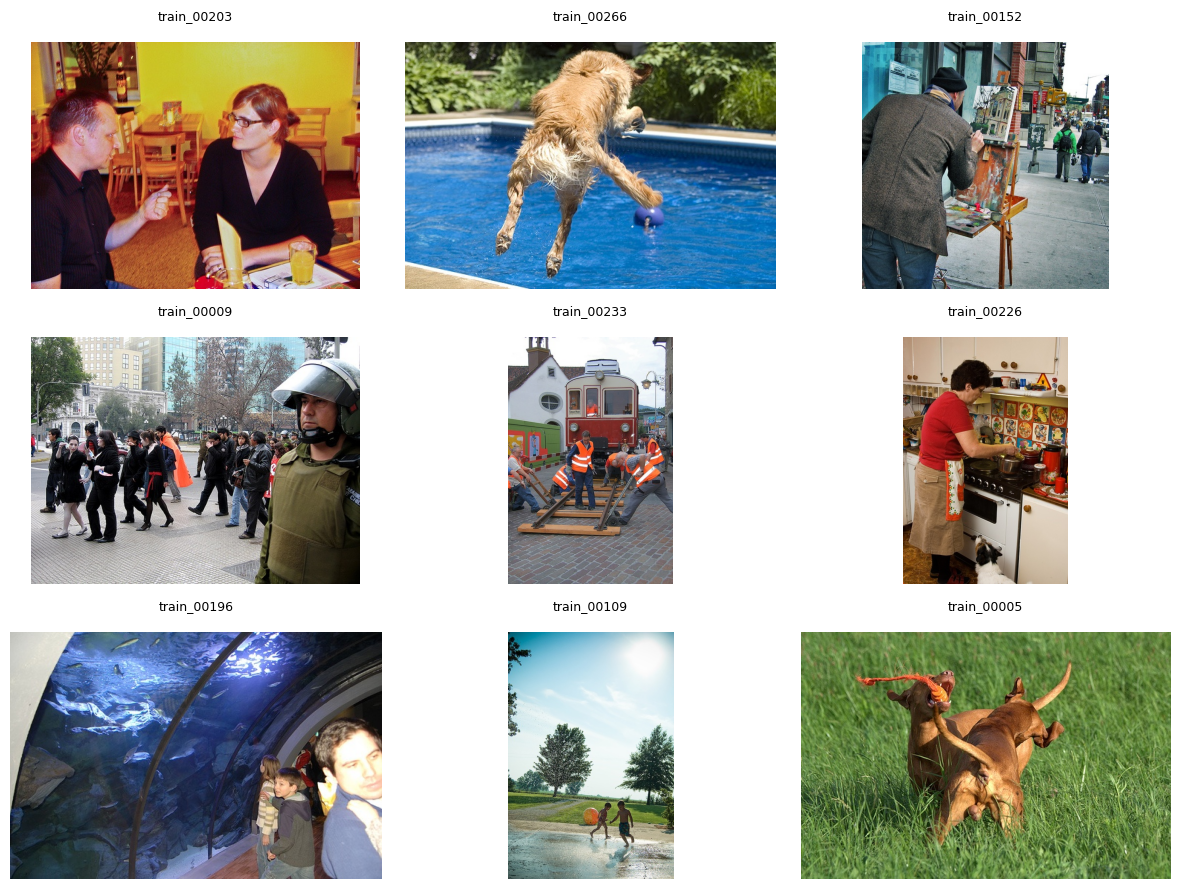

In [7]:
sample_gallery = metadata.sample(n=min(9, len(metadata)), random_state=RANDOM_STATE).reset_index(drop=True)
show_gallery(sample_gallery, ncols=3, figsize=(12, 9))
plt.show()


#### **2. Construcción o carga de embeddings**

Los *embeddings* se guardan con un nombre que codifica dataset, arquitectura y *checkpoint*. La celda valida que el archivo `.npz` corresponda exactamente al CSV activo, al número actual de imágenes y al número actual de captions. Si detecta un archivo desactualizado, lo elimina y lo reconstruye automáticamente.

Esto evita reutilizar resultados generados con una versión anterior del subconjunto o con otra expansión de captions.

In [8]:
def slug(text):
    return ''.join(ch.lower() if ch.isalnum() else '_' for ch in str(text)).strip('_')


def _npz_scalar(bundle, key, default=''):
    """Lee valores escalares guardados en un .npz de forma robusta."""
    if key not in bundle.files:
        return default
    value = bundle[key]
    try:
        if getattr(value, 'shape', None) == ():
            return str(value.item())
        if len(value) == 1:
            return str(value[0])
    except Exception:
        pass
    return str(value)


def embedding_bundle_matches(output_path, metadata_csv_path, model_name, pretrained, root=PROJECT_ROOT):
    """Valida que un archivo de embeddings corresponda al metadata/caption set activo.

    Esta validación evita reutilizar archivos `.npz` generados con una versión anterior del
    CSV, con otro número de captions o con otro checkpoint. Es especialmente importante
    cuando se alterna entre el bootstrap y el subconjunto Flickr1k ampliado.
    """
    output_path = Path(output_path)
    metadata_csv_path = Path(metadata_csv_path)

    if not output_path.exists():
        return False, 'no existe'

    try:
        local_metadata = load_metadata(metadata_csv_path, root=root)
        local_caption_df, _, _ = build_caption_targets(local_metadata)

        with np.load(output_path, allow_pickle=True) as bundle:
            required = {'image_features', 'text_features'}
            missing = sorted(required - set(bundle.files))
            if missing:
                return False, f'faltan claves en el npz: {missing}'

            image_features_local = bundle['image_features']
            text_features_local = bundle['text_features']

            if image_features_local.shape[0] != len(local_metadata):
                return (
                    False,
                    f'imágenes esperadas={len(local_metadata)}, encontradas={image_features_local.shape[0]}',
                )

            if text_features_local.shape[0] != len(local_caption_df):
                return (
                    False,
                    f'captions esperadas={len(local_caption_df)}, encontradas={text_features_local.shape[0]}',
                )

            if 'caption_ids' in bundle.files and len(bundle['caption_ids']) != len(local_caption_df):
                return (
                    False,
                    f'caption_ids esperados={len(local_caption_df)}, encontrados={len(bundle["caption_ids"])}',
                )

            saved_model = _npz_scalar(bundle, 'model_name', '')
            saved_pretrained = _npz_scalar(bundle, 'pretrained', '')
            if saved_model and saved_model != str(model_name):
                return False, f'modelo guardado={saved_model}, modelo activo={model_name}'
            if saved_pretrained and saved_pretrained != str(pretrained):
                return False, f'checkpoint guardado={saved_pretrained}, checkpoint activo={pretrained}'

            saved_metadata_path = _npz_scalar(bundle, 'metadata_csv_path', '')
            if saved_metadata_path:
                try:
                    if Path(saved_metadata_path).resolve() != metadata_csv_path.resolve():
                        return (
                            False,
                            f'metadata guardado={saved_metadata_path}, metadata activo={metadata_csv_path.resolve()}',
                        )
                except Exception:
                    # Si la ruta guardada no puede resolverse, no se bloquea la ejecución.
                    pass

        return True, 'válido'
    except Exception as exc:
        return False, f'no se pudo validar: {type(exc).__name__}: {exc}'


def build_embeddings(metadata_csv_path, output_path, model_name, pretrained, batch_size=BATCH_SIZE):
    """Construye embeddings con el script oficial del proyecto."""
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    build_cmd = [
        sys.executable,
        str(PROJECT_ROOT / 'scripts' / '02_build_embeddings.py'),
        '--metadata-csv', str(metadata_csv_path),
        '--model-name', model_name,
        '--pretrained', pretrained,
        '--batch-size', str(batch_size),
        '--output', str(output_path),
    ]
    print('Construyendo embeddings:')
    print(' '.join(build_cmd))
    subprocess.run(build_cmd, cwd=PROJECT_ROOT, check=True)


def remove_if_exists(path):
    path = Path(path)
    if path.exists():
        path.unlink()
        print(f'Archivo eliminado por estar desactualizado: {path.relative_to(PROJECT_ROOT)}')


embedding_tag = f'{dataset_id}_{slug(MODEL_NAME)}_{slug(PRETRAINED)}'
emb_path = PATHS['embeddings'] / f'{embedding_tag}.npz'

is_valid_embedding, validation_message = embedding_bundle_matches(
    emb_path,
    metadata_csv,
    MODEL_NAME,
    PRETRAINED,
    root=PROJECT_ROOT,
)

if not is_valid_embedding:
    if emb_path.exists():
        print(f'Embeddings existentes no reutilizables: {validation_message}')
        remove_if_exists(emb_path)

        # Archivos derivados que podrían quedar inconsistentes si cambió el número de captions.
        remove_if_exists(PROJECT_ROOT / 'outputs' / 'faiss' / f'query_results_{dataset_id}.csv')
        remove_if_exists(PATHS['metrics'] / f'retrieval_metrics_{dataset_id}.csv')

    build_embeddings(metadata_csv, emb_path, MODEL_NAME, PRETRAINED, batch_size=BATCH_SIZE)
else:
    print(f'Embeddings existentes válidos: {emb_path.relative_to(PROJECT_ROOT)}')

# Carga final y verificación explícita.
with np.load(emb_path, allow_pickle=True) as bundle_loaded:
    image_features = bundle_loaded['image_features']
    text_features = bundle_loaded['text_features']
    bundle_metadata_csv_path = _npz_scalar(bundle_loaded, 'metadata_csv_path', 'no registrado')
    bundle_model_name = _npz_scalar(bundle_loaded, 'model_name', MODEL_NAME)
    bundle_pretrained = _npz_scalar(bundle_loaded, 'pretrained', PRETRAINED)

# Se mantiene un bundle abierto para celdas posteriores que consultan model_name/pretrained.
bundle = np.load(emb_path, allow_pickle=True)

assert image_features.shape[0] == len(metadata), (
    f'El número de embeddings de imagen no coincide con metadata: '
    f'{image_features.shape[0]} vs {len(metadata)}.'
)
assert text_features.shape[0] == len(caption_df), (
    f'El número de embeddings de texto no coincide con captions: '
    f'{text_features.shape[0]} vs {len(caption_df)}. '
    'Si el segundo número es anormalmente grande, reinicie el kernel y ejecute la celda '
    'de preparación de datos corregida para restaurar all_captions como lista.'
)

print('image_features:', image_features.shape)
print('text_features:', text_features.shape)
print('metadata_csv_path:', bundle_metadata_csv_path)
print('model/checkpoint:', bundle_model_name, '/', bundle_pretrained)


Construyendo embeddings:
/usr/local/bin/python /workspace/Semana5/Proyecto/scripts/02_build_embeddings.py --metadata-csv /workspace/Semana5/Proyecto/data/flickr1k_eval_300/train.csv --model-name ViT-B-32 --pretrained laion2b_s34b_b79k --batch-size 32 --output /workspace/Semana5/Proyecto/outputs/embeddings/flickr1k_eval_300_vit_b_32_laion2b_s34b_b79k.npz


/usr/local/lib/python3.11/site-packages/open_clip/factory.py:129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=map_loc

Saved embeddings to /workspace/Semana5/Proyecto/outputs/embeddings/flickr1k_eval_300_vit_b_32_laion2b_s34b_b79k.npz
image_features: (300, 512)
text_features: (1500, 512)
metadata_csv_path: /workspace/Semana5/Proyecto/data/flickr1k_eval_300/train.csv
model/checkpoint: ViT-B-32 / laion2b_s34b_b79k


#### **3. Evaluación de recuperación multicaption**

Se evalúan dos direcciones: **imagen -> texto** y **texto -> imagen**. Como una imagen puede tener varias captions válidas, la evaluación imagen->texto usa positivos múltiples. Se reportan `R@1`, `R@5`, `R@10`, `MRR`, `MeanRank` y `MedianRank`.

En este laboratorio estas métricas deben acompañarse de interpretación: no basta con afirmar que un valor es alto, debe discutirse la escala del conjunto, la diversidad semántica, los casos de error y la relación entre desempeño y costo.


In [9]:
sim = compute_similarity_matrix(image_features, text_features)
text_positive = {idx: [img_idx] for idx, img_idx in text_to_image.items()}
image_to_text_metrics = summarize_multi_target_ranking(sim, image_to_text)
text_to_image_metrics = summarize_multi_target_ranking(sim.T, text_positive)

retrieval_metrics_df = pd.DataFrame([
    {'direction': 'image_to_text', **{k: v for k, v in image_to_text_metrics.items() if k != 'Ranks'}},
    {'direction': 'text_to_image', **{k: v for k, v in text_to_image_metrics.items() if k != 'Ranks'}},
])
retrieval_metrics_path = PATHS['metrics'] / f'retrieval_metrics_{dataset_id}.csv'
retrieval_metrics_df.to_csv(retrieval_metrics_path, index=False)
display(retrieval_metrics_df)
print(f'Métricas guardadas en: {retrieval_metrics_path.relative_to(PROJECT_ROOT)}')


def interpret_retrieval(row, n_items):
    r1 = float(row['R@1'])
    mrr = float(row['MRR'])
    direction = row['direction']
    if r1 >= 0.80:
        strength = 'muy alto'
    elif r1 >= 0.50:
        strength = 'moderado-alto'
    elif r1 >= 0.25:
        strength = 'intermedio'
    else:
        strength = 'bajo'
    caution = ' La escala del subconjunto es pequeña, evite conclusiones generales.' if n_items < 100 else ''
    return f'En {direction}, R@1={r1:.3f} y MRR={mrr:.3f}, desempeño {strength} para {n_items} consultas evaluadas.{caution}'

for _, row in retrieval_metrics_df.iterrows():
    n_items = len(metadata) if row['direction'] == 'image_to_text' else len(caption_df)
    print('-', interpret_retrieval(row, n_items))


,direction,R@1,R@5,R@10,MRR,MeanRank,MedianRank
0,image_to_text,0.903333,0.980,0.990000,0.939224,1.540,1.0
1,text_to_image,0.790667,0.952,0.971333,0.860961,2.234,1.0


Métricas guardadas en: outputs/metrics/retrieval_metrics_flickr1k_eval_300.csv
- En image_to_text, R@1=0.903 y MRR=0.939, desempeño muy alto para 300 consultas evaluadas.
- En text_to_image, R@1=0.791 y MRR=0.861, desempeño moderado-alto para 1500 consultas evaluadas.


##### **3.1 Visualizaciones *top-k* de recuperación**

Las métricas agregadas pueden ocultar errores sistemáticos. Las siguientes funciones visualizan los resultados de texto->imagen e imagen->texto. En el reporte final, el estudiante debe comentar al menos tres aciertos y tres errores relevantes.


,rank,image_id,filepath,caption,score
0,1,train_00226,/workspace/Semana5/Proyecto/data/flickr1k_eval...,A woman cooks on the stove in her kitchen as h...,0.310071
1,2,train_00072,/workspace/Semana5/Proyecto/data/flickr1k_eval...,An Asian woman and an African American woman a...,0.295119
2,3,train_00150,/workspace/Semana5/Proyecto/data/flickr1k_eval...,Four men and women in blue aprons strand in fr...,0.284513
3,4,train_00213,/workspace/Semana5/Proyecto/data/flickr1k_eval...,A man sitting down with this head resting on h...,0.277124
4,5,train_00283,/workspace/Semana5/Proyecto/data/flickr1k_eval...,A young woman is stirring something in a pot w...,0.262710


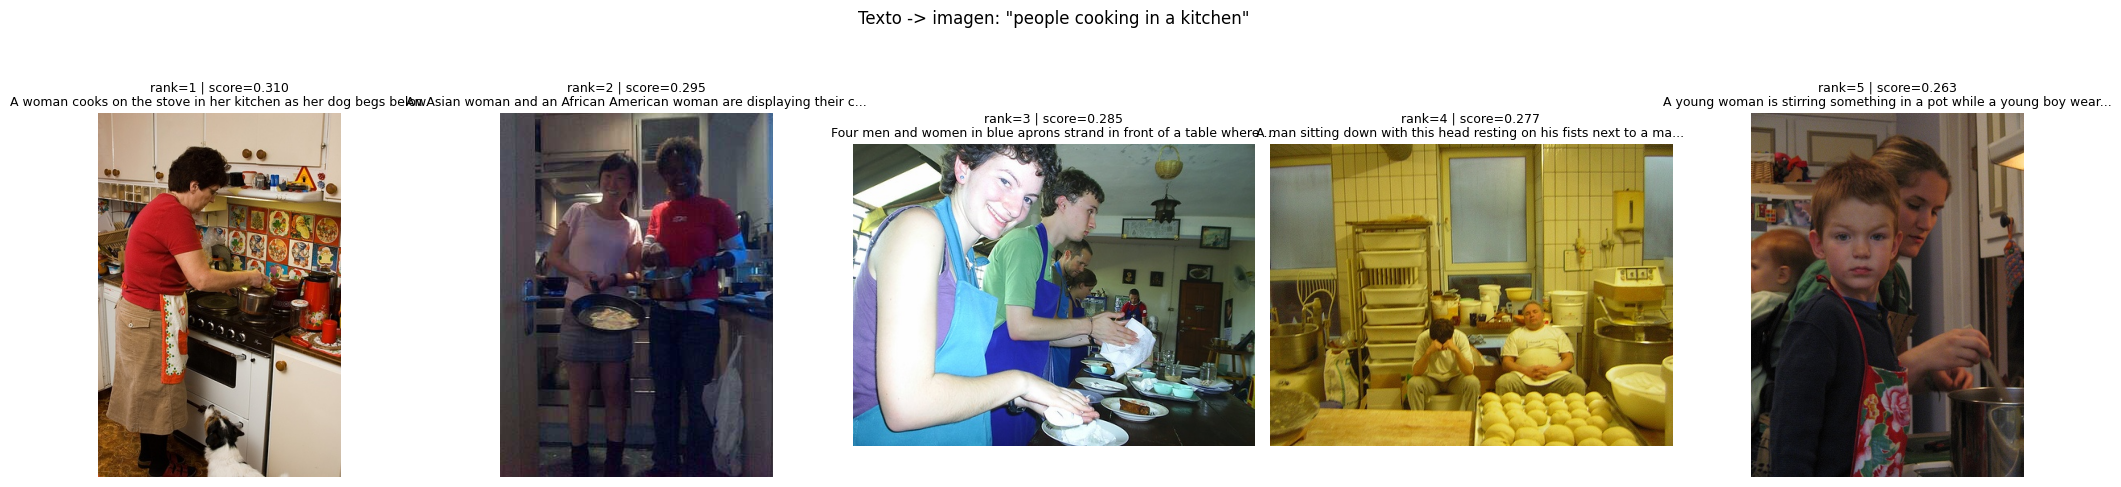

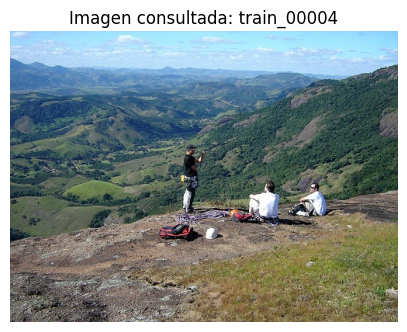

,rank,image_id,caption_id,caption,score
0,1,train_00004,train_00004_0,Three people are on a hilltop overlooking a gr...,0.367117
1,2,train_00004,train_00004_4,Three people overlook a green valley.,0.349352
2,3,train_00004,train_00004_1,People sit on the mountainside and check out t...,0.342275
3,4,train_00004,train_00004_3,Three people hang out on top of a big hill.,0.333042
4,5,train_00004,train_00004_2,Three people rest on a ledge above the moutains.,0.325201


In [10]:
def plot_text_to_image_results(query, k=5):
    """Visualiza recuperación texto->imagen sin propagar valores vacíos a títulos o tablas."""
    model_name = str(bundle['model_name'])
    pretrained = str(bundle['pretrained'])
    model, _, tokenizer, device = create_model(model_name, pretrained)

    safe_query = clean_text(query, fallback="consulta sin texto")
    q_feat = encode_texts(model, tokenizer, [safe_query], device)
    results = topk_text_to_image(q_feat, image_features, metadata, k=k)
    results = sanitize_dataframe_values(results)

    if len(results) == 0:
        display(Markdown(f'No se encontraron resultados para la consulta: `{safe_query}`.'))
        return results

    fig, axes = plt.subplots(1, len(results), figsize=(4.2 * len(results), 4.6))
    if len(results) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, results.iterrows()):
        try:
            image_path = resolve_project_path(row.get('filepath', ''))
            img = Image.open(image_path).convert('RGB')
            ax.imshow(img)
        except Exception as exc:
            ax.text(
                0.5,
                0.5,
                f"No se pudo cargar la imagen\n{type(exc).__name__}",
                ha="center",
                va="center",
            )

        rank = clean_text(row.get('rank', ''), fallback='?')
        caption = shorten_text(row.get('caption', ''), max_chars=70, fallback='sin caption')

        try:
            score_text = f"{float(row.get('score', 0.0)):.3f}"
        except Exception:
            score_text = clean_text(row.get('score', ''), fallback='sin score')

        # No se muestra label en el título cuando el dataset no tiene etiquetas cerradas.
        ax.set_title(f"rank={rank} | score={score_text}\n{caption}", fontsize=9)
        ax.axis('off')

    plt.suptitle(f'Texto -> imagen: "{safe_query}"', y=1.05)
    plt.tight_layout()

    display_columns = ['rank', 'image_id', 'filepath', 'label', 'caption', 'score']
    display_clean_dataframe(results, columns=display_columns, hide_empty_label=True)
    return results


def display_image_to_text_results(image_index, k=5):
    """Visualiza recuperación imagen->texto sin mostrar valores vacíos en títulos o tablas."""
    image_index = int(image_index)
    row = sanitize_dataframe_values(pd.DataFrame([metadata.iloc[image_index]])).iloc[0]
    image_id = clean_text(row.get("image_id", image_index), fallback=str(image_index))
    image_path = resolve_project_path(row.get('filepath', ''))

    plt.figure(figsize=(5, 5))
    try:
        img = Image.open(image_path).convert('RGB')
        plt.imshow(img)
    except Exception as exc:
        plt.text(
            0.5,
            0.5,
            f"No se pudo cargar la imagen\n{type(exc).__name__}",
            ha="center",
            va="center",
        )
    plt.title(f'Imagen consultada: {image_id}')
    plt.axis('off')
    plt.show()

    results = sanitize_dataframe_values(topk_image_to_text(image_index, sim, caption_df, k=k))
    display_clean_dataframe(
        results,
        columns=['rank', 'image_id', 'caption_id', 'caption', 'score'],
        hide_empty_label=True,
    )
    return results


query_results = plot_text_to_image_results('people cooking in a kitchen', k=5)
image_query_results = display_image_to_text_results(image_index=min(4, len(metadata) - 1), k=5)


#### **4. Clasificación zero-shot, plantillas y matriz de confusión**

La evaluación *zero-shot* compara plantillas individuales frente a un *prompt ensemble*. Esta sección es experimentalmente obligatoria solo si el dataset activo contiene etiquetas cerradas no vacías y compatibles con `prompt_config.json`. Si el subconjunto ampliado no tiene etiquetas, se ejecuta el bootstrap etiquetado y se marca como **demostración elemental**, no como evidencia concluyente.


In [11]:
def build_embeddings_if_needed(metadata_csv_path, output_path, model_name, pretrained):
    is_valid, reason = embedding_bundle_matches(
        output_path,
        metadata_csv_path,
        model_name,
        pretrained,
        root=PROJECT_ROOT,
    )
    if is_valid:
        return
    if Path(output_path).exists():
        print(f'Embeddings auxiliares no reutilizables: {reason}')
        Path(output_path).unlink()
    build_embeddings(metadata_csv_path, output_path, model_name, pretrained, batch_size=BATCH_SIZE)


if non_empty_labels:
    zeroshot_metadata_csv = metadata_csv
    zeroshot_emb_path = emb_path
    zeroshot_mode = 'evaluacion_etiquetada_principal'
else:
    zeroshot_metadata_csv = BOOTSTRAP_METADATA_CSV
    zeroshot_emb_path = PATHS['embeddings'] / f'bootstrap_flickr30k_{slug(MODEL_NAME)}_{slug(PRETRAINED)}.npz'
    zeroshot_mode = 'demostracion_bootstrap'
    build_embeddings_if_needed(zeroshot_metadata_csv, zeroshot_emb_path, MODEL_NAME, PRETRAINED)
    display(Markdown(
        '**Aviso:** el subconjunto ampliado no contiene etiquetas cerradas compatibles. '
        'La evaluación zero-shot cerrada se ejecuta sobre el bootstrap etiquetado y debe '
        'reportarse como demostrativa, no como evidencia experimental concluyente.'
    ))

zs_summary = PATHS['metrics'] / f'zeroshot_prompt_summary_{zeroshot_mode}.csv'
zs_preds = PATHS['metrics'] / f'zeroshot_predictions_{zeroshot_mode}.csv'
zs_conf = PATHS['metrics'] / f'zeroshot_confusion_{zeroshot_mode}.csv'

if not zs_summary.exists():
    zs_cmd = [
        sys.executable,
        str(PROJECT_ROOT / 'scripts' / '04_eval_zeroshot_prompt_ensembles.py'),
        '--embeddings', str(zeroshot_emb_path),
        '--metadata-csv', str(zeroshot_metadata_csv),
        '--prompt-config', str(PROMPT_CONFIG_JSON),
        '--output-summary', str(zs_summary),
        '--output-predictions', str(zs_preds),
        '--output-confusion', str(zs_conf),
    ]
    print('Ejecutando evaluación zero-shot:')
    print(' '.join(zs_cmd))
    subprocess.run(zs_cmd, cwd=PROJECT_ROOT, check=True)

# keep_default_na=False evita que campos vacíos se vean como NaN en tablas.
zs_summary_df = pd.read_csv(zs_summary, keep_default_na=False)
zs_predictions_df = pd.read_csv(zs_preds, keep_default_na=False)
zs_confusion_df = pd.read_csv(zs_conf, index_col=0)

if 'template' in zs_summary_df.columns:
    zs_summary_df['template'] = (
        zs_summary_df['template']
        .astype(str)
        .str.replace(' | ', '; ', regex=False)
    )

if 'accuracy' in zs_summary_df.columns:
    zs_summary_df['accuracy'] = pd.to_numeric(zs_summary_df['accuracy'], errors='coerce')
    zs_summary_df['accuracy_pct'] = (100 * zs_summary_df['accuracy']).round(2)

display(Markdown(f'**Modo zero-shot:** `{zeroshot_mode}`'))

if zeroshot_mode == 'demostracion_bootstrap':
    display(Markdown(
        '**Nota metodológica:** la evaluación zero-shot cerrada se ejecuta sobre el subconjunto '
        'bootstrap simple porque el subconjunto ampliado no contiene etiquetas cerradas compatibles. '
        'Por tanto, estos resultados verifican el funcionamiento del flujo de clasificación zero-shot, '
        'pero no constituyen evidencia experimental concluyente.'
    ))

summary_columns = ['mode', 'template', 'accuracy', 'accuracy_pct']
zs_summary_display_df = clean_dataframe_for_display(
    zs_summary_df[summary_columns].sort_values('accuracy', ascending=False),
    hide_empty_label=True,
)
display(zs_summary_display_df)

pred_columns = ['image_id', 'filepath', 'label', 'prediction', 'score']
display_clean_dataframe(zs_predictions_df, columns=pred_columns, n=10, hide_empty_label=False)


Construyendo embeddings:
/usr/local/bin/python /workspace/Semana5/Proyecto/scripts/02_build_embeddings.py --metadata-csv /workspace/Semana5/Proyecto/data/bootstrap_flickr30k/metadata.csv --model-name ViT-B-32 --pretrained laion2b_s34b_b79k --batch-size 32 --output /workspace/Semana5/Proyecto/outputs/embeddings/bootstrap_flickr30k_vit_b_32_laion2b_s34b_b79k.npz


/usr/local/lib/python3.11/site-packages/open_clip/factory.py:129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=map_loc

Saved embeddings to /workspace/Semana5/Proyecto/outputs/embeddings/bootstrap_flickr30k_vit_b_32_laion2b_s34b_b79k.npz


**Aviso:** el subconjunto ampliado no contiene etiquetas cerradas compatibles. La evaluación zero-shot cerrada se ejecuta sobre el bootstrap etiquetado y debe reportarse como demostrativa, no como evidencia experimental concluyente.

Ejecutando evaluación zero-shot:
/usr/local/bin/python /workspace/Semana5/Proyecto/scripts/04_eval_zeroshot_prompt_ensembles.py --embeddings /workspace/Semana5/Proyecto/outputs/embeddings/bootstrap_flickr30k_vit_b_32_laion2b_s34b_b79k.npz --metadata-csv /workspace/Semana5/Proyecto/data/bootstrap_flickr30k/metadata.csv --prompt-config /workspace/Semana5/Proyecto/data/bootstrap_flickr30k/prompt_config.json --output-summary /workspace/Semana5/Proyecto/outputs/metrics/zeroshot_prompt_summary_demostracion_bootstrap.csv --output-predictions /workspace/Semana5/Proyecto/outputs/metrics/zeroshot_predictions_demostracion_bootstrap.csv --output-confusion /workspace/Semana5/Proyecto/outputs/metrics/zeroshot_confusion_demostracion_bootstrap.csv


...

**Modo zero-shot:** `demostracion_bootstrap`

**Nota metodológica:** la evaluación zero-shot cerrada se ejecuta sobre el subconjunto bootstrap simple porque el subconjunto ampliado no contiene etiquetas cerradas compatibles. Por tanto, estos resultados verifican el funcionamiento del flujo de clasificación zero-shot, pero no constituyen evidencia experimental concluyente.

,mode,template,accuracy,accuracy_pct
0,prompt_ensemble,a photo of {}; an image of {}; a caption about {},0.833333,83.33
1,single_template,a photo of {},0.833333,83.33
2,single_template,an image of {},0.833333,83.33
3,single_template,a caption about {},0.833333,83.33


,image_id,filepath,label
0,flickr30k_0000,/workspace/Semana5/Proyecto/data/bootstrap_fli...,people_outdoors
1,flickr30k_0001,/workspace/Semana5/Proyecto/data/bootstrap_fli...,industrial_workers
2,flickr30k_0002,/workspace/Semana5/Proyecto/data/bootstrap_fli...,child_play
3,flickr30k_0003,/workspace/Semana5/Proyecto/data/bootstrap_fli...,maintenance
4,flickr30k_0004,/workspace/Semana5/Proyecto/data/bootstrap_fli...,cooking
5,flickr30k_0005,/workspace/Semana5/Proyecto/data/bootstrap_fli...,performance


,image_id,filepath,label
0,flickr30k_0000,/workspace/Semana5/Proyecto/data/bootstrap_fli...,people_outdoors
1,flickr30k_0001,/workspace/Semana5/Proyecto/data/bootstrap_fli...,industrial_workers
2,flickr30k_0002,/workspace/Semana5/Proyecto/data/bootstrap_fli...,child_play
3,flickr30k_0003,/workspace/Semana5/Proyecto/data/bootstrap_fli...,maintenance
4,flickr30k_0004,/workspace/Semana5/Proyecto/data/bootstrap_fli...,cooking
5,flickr30k_0005,/workspace/Semana5/Proyecto/data/bootstrap_fli...,performance


#### **Interpretación de la evaluación zero-shot**

La evaluación zero-shot se reporta en modo demostrativo cuando el conjunto ampliado no dispone de etiquetas cerradas compatibles con las clases definidas en `prompt_config.json`. En ese caso, el cuaderno usa el subconjunto bootstrap etiquetado para verificar que el flujo completo funciona: codificación de imágenes, construcción de prompts, codificación textual, comparación imagen-texto, predicción de clase y cálculo de matriz de confusión.

La exactitud obtenida debe interpretarse con cautela. Al tratarse de un conjunto pequeño, el valor numérico puede variar de manera significativa ante cambios mínimos en las imágenes, las plantillas de prompt o el checkpoint utilizado. Por ello, este resultado no debe presentarse como una estimación robusta del desempeño del modelo, sino como una comprobación controlada del procedimiento metodológico.

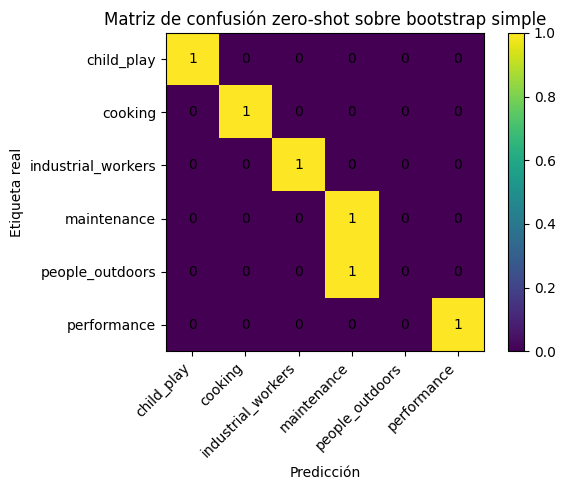

Figura guardada en: outputs/figures/zeroshot_confusion_demostracion_bootstrap.png


In [12]:
def plot_confusion_matrix(confusion_df, title='Matriz de confusión zero-shot'):
    """Grafica matriz de confusión con etiquetas limpias y valores numéricos seguros."""
    clean_index = [clean_text(label, fallback='sin_etiqueta') for label in confusion_df.index]
    clean_columns = [clean_text(label, fallback='sin_prediccion') for label in confusion_df.columns]
    values_df = confusion_df.apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

    fig, ax = plt.subplots(
        figsize=(
            max(7, 0.7 * len(clean_columns)),
            max(5, 0.6 * len(clean_index)),
        )
    )
    im = ax.imshow(values_df.values)
    ax.set_xticks(np.arange(len(clean_columns)))
    ax.set_yticks(np.arange(len(clean_index)))
    ax.set_xticklabels(clean_columns, rotation=45, ha='right')
    ax.set_yticklabels(clean_index)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Etiqueta real')
    ax.set_title(clean_text(title, fallback='Matriz de confusión zero-shot'))

    for i in range(values_df.shape[0]):
        for j in range(values_df.shape[1]):
            ax.text(j, i, int(values_df.iloc[i, j]), ha='center', va='center')

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    return fig


conf_title = (
    'Matriz de confusión zero-shot sobre bootstrap simple'
    if zeroshot_mode == 'demostracion_bootstrap'
    else 'Matriz de confusión zero-shot'
)
conf_fig = plot_confusion_matrix(zs_confusion_df, title=conf_title)
confusion_png = PATHS['figures'] / f'zeroshot_confusion_{zeroshot_mode}.png'
conf_fig.savefig(confusion_png, dpi=160, bbox_inches='tight')
plt.show()
print(f'Figura guardada en: {confusion_png.relative_to(PROJECT_ROOT)}')


#### **5. Comparación de checkpoints y costo computacional**

La comparación entre *checkpoints* no debe reducirse a "cuál obtuvo la mejor métrica". También debe documentarse costo: tiempo de cómputo, GPU, tamaño de batch, número de imágenes, número de captions y fallos. La medición por *checkpoint* está desactivada por defecto porque puede tardar y descargar pesos adicionales.


In [13]:
ckpt_cmp = PATHS['metrics'] / f'checkpoint_comparison_{dataset_id}.csv'
if not ckpt_cmp.exists():
    ckpt_cmd = [
        sys.executable,
        str(PROJECT_ROOT / 'scripts' / '05_compare_checkpoints.py'),
        '--metadata-csv', str(metadata_csv),
        '--checkpoint-config', str(PROJECT_ROOT / 'configs' / 'checkpoints.yaml'),
        '--prompt-config', str(PROMPT_CONFIG_JSON),
        '--output-csv', str(ckpt_cmp),
    ]
    print('Comparando checkpoints:')
    print(' '.join(ckpt_cmd))
    subprocess.run(ckpt_cmd, cwd=PROJECT_ROOT, check=True)

checkpoint_comparison_df = pd.read_csv(ckpt_cmp, keep_default_na=False)
display_clean_dataframe(checkpoint_comparison_df, hide_empty_label=True)


Comparando checkpoints:
/usr/local/bin/python /workspace/Semana5/Proyecto/scripts/05_compare_checkpoints.py --metadata-csv /workspace/Semana5/Proyecto/data/flickr1k_eval_300/train.csv --checkpoint-config /workspace/Semana5/Proyecto/configs/checkpoints.yaml --prompt-config /workspace/Semana5/Proyecto/data/bootstrap_flickr30k/prompt_config.json --output-csv /workspace/Semana5/Proyecto/outputs/metrics/checkpoint_comparison_flickr1k_eval_300.csv


/usr/local/lib/python3.11/site-packages/open_clip/factory.py:129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=map_loc

Saved /workspace/Semana5/Proyecto/outputs/metrics/checkpoint_comparison_flickr1k_eval_300.csv


,tag,model_name,pretrained,i2t_R@1,i2t_MRR,t2i_R@1,t2i_MRR,zeroshot_ensemble_acc,status
0,vit_b32_laion2b,ViT-B-32,laion2b_s34b_b79k,0.903333,0.939224,0.790667,0.860961,0.0,ok
1,vit_b16_datacomp,ViT-B-16,datacomp_xl_s13b_b90k,0.920000,0.952143,0.802667,0.870873,0.0,ok
2,vit_l14_openai,ViT-L-14,openai,0.903333,0.944756,0.764667,0.844261,0.0,ok


,tag,model_name,pretrained,i2t_R@1,i2t_MRR,t2i_R@1,t2i_MRR,zeroshot_ensemble_acc,status
0,vit_b32_laion2b,ViT-B-32,laion2b_s34b_b79k,0.903333,0.939224,0.790667,0.860961,0.0,ok
1,vit_b16_datacomp,ViT-B-16,datacomp_xl_s13b_b90k,0.920000,0.952143,0.802667,0.870873,0.0,ok
2,vit_l14_openai,ViT-L-14,openai,0.903333,0.944756,0.764667,0.844261,0.0,ok


In [14]:
MEASURE_CHECKPOINT_COST = False
checkpoint_cost_path = PATHS['metrics'] / f'checkpoint_cost_{dataset_id}.csv'

if MEASURE_CHECKPOINT_COST:
    import yaml
    config = yaml.safe_load((PROJECT_ROOT / 'configs' / 'checkpoints.yaml').read_text(encoding='utf-8'))
    cost_rows = []
    for ckpt in config['checkpoints']:
        single_config = {'checkpoints': [ckpt]}
        tmp_config = PATHS['metadata'] / f"tmp_checkpoint_{ckpt['tag']}.yaml"
        tmp_config.write_text(yaml.safe_dump(single_config, sort_keys=False), encoding='utf-8')
        tmp_output = PATHS['metrics'] / f"tmp_checkpoint_result_{dataset_id}_{ckpt['tag']}.csv"
        start = time.perf_counter()
        status, error = 'ok', ''
        try:
            subprocess.run(
                [
                    sys.executable,
                    str(PROJECT_ROOT / 'scripts' / '05_compare_checkpoints.py'),
                    '--metadata-csv', str(metadata_csv),
                    '--checkpoint-config', str(tmp_config),
                    '--prompt-config', str(PROMPT_CONFIG_JSON),
                    '--output-csv', str(tmp_output),
                ],
                cwd=PROJECT_ROOT,
                check=True,
            )
        except Exception as exc:
            status, error = 'error', repr(exc)
        seconds = time.perf_counter() - start
        cost_rows.append({
            'tag': ckpt['tag'],
            'model_name': ckpt['model_name'],
            'pretrained': ckpt['pretrained'],
            'n_images': len(metadata),
            'n_captions': len(caption_df),
            'batch_size': BATCH_SIZE,
            'seconds_wall_clock': round(seconds, 2),
            'minutes_wall_clock': round(seconds / 60, 2),
            'gpu_name': environment_record.get('gpu_name'),
            'cuda_available': environment_record.get('cuda_available'),
            'status': status,
            'error': error,
        })
    checkpoint_cost_df = pd.DataFrame(cost_rows)
    checkpoint_cost_df.to_csv(checkpoint_cost_path, index=False)
else:
    if checkpoint_cost_path.exists():
        checkpoint_cost_df = pd.read_csv(checkpoint_cost_path, keep_default_na=False)
    else:
        checkpoint_cost_df = pd.DataFrame([{
            'nota': 'Costo no medido en esta ejecución. Cambie MEASURE_CHECKPOINT_COST=True para registrar tiempo por checkpoint.',
            'n_images': len(metadata),
            'n_captions': len(caption_df),
            'gpu_name': clean_text(environment_record.get('gpu_name'), fallback='no_disponible'),
            'cuda_available': environment_record.get('cuda_available'),
        }])

display_clean_dataframe(checkpoint_cost_df, hide_empty_label=True)


,nota,n_images,n_captions,gpu_name,cuda_available
0,Costo no medido en esta ejecución. Cambie MEAS...,300,1500,no_disponible,False


,nota,n_images,n_captions,gpu_name,cuda_available
0,Costo no medido en esta ejecución. Cambie MEAS...,300,1500,no_disponible,False


#### **6. FAISS como extensión aplicada**

FAISS convierte la evaluación de similitud en una búsqueda vectorial operativa. En esta práctica se usa como extensión aplicada: ayuda a discutir cómo un prototipo de recuperación imagen-texto podría integrarse en un sistema real. No reemplaza las métricas de recuperación ni el análisis de errores.


Ejecutando búsqueda FAISS:
/usr/local/bin/python /workspace/Semana5/Proyecto/scripts/06_build_faiss_index.py --embeddings /workspace/Semana5/Proyecto/outputs/embeddings/flickr1k_eval_300_vit_b_32_laion2b_s34b_b79k.npz --metadata-csv /workspace/Semana5/Proyecto/data/flickr1k_eval_300/train.csv --queries-csv /workspace/Semana5/Proyecto/data/bootstrap_flickr30k/queries.csv --output-csv /workspace/Semana5/Proyecto/outputs/faiss/query_results_flickr1k_eval_300.csv


/usr/local/lib/python3.11/site-packages/open_clip/factory.py:129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=map_loc

Saved /workspace/Semana5/Proyecto/outputs/faiss/query_results_flickr1k_eval_300.csv


,query,rank,image_id,filepath,caption,score
0,two men in a yard,1,train_00275,/workspace/Semana5/Proyecto/data/flickr1k_eval...,Two young guys with shaggy hair look at their ...,0.275248
1,two men in a yard,2,train_00112,/workspace/Semana5/Proyecto/data/flickr1k_eval...,A man is standing in a forest practicing a mar...,0.270736
2,two men in a yard,3,train_00204,/workspace/Semana5/Proyecto/data/flickr1k_eval...,Construction workers standing on top of a piec...,0.261019
3,workers on a machine with hard hats,1,train_00120,/workspace/Semana5/Proyecto/data/flickr1k_eval...,A construction site on a street with three men...,0.304003
4,workers on a machine with hard hats,2,train_00263,/workspace/Semana5/Proyecto/data/flickr1k_eval...,A child and a young adult the adult is maybe d...,0.288910
5,workers on a machine with hard hats,3,train_00204,/workspace/Semana5/Proyecto/data/flickr1k_eval...,Construction workers standing on top of a piec...,0.281317
6,little girl climbing into a wooden playhouse,1,train_00025,/workspace/Semana5/Proyecto/data/flickr1k_eval...,A child in a pink dress is climbing up a set o...,0.371575
7,little girl climbing into a wooden playhouse,2,train_00012,/workspace/Semana5/Proyecto/data/flickr1k_eval...,A man wearing a blue jacket and glasses holds ...,0.297909
8,little girl climbing into a wooden playhouse,3,train_00162,/workspace/Semana5/Proyecto/data/flickr1k_eval...,A baby wearing a white shirt is crawling on th...,0.268045
9,man cleaning a window on a ladder,1,train_00071,/workspace/Semana5/Proyecto/data/flickr1k_eval...,"An older, male construction worker wearing a y...",0.293665


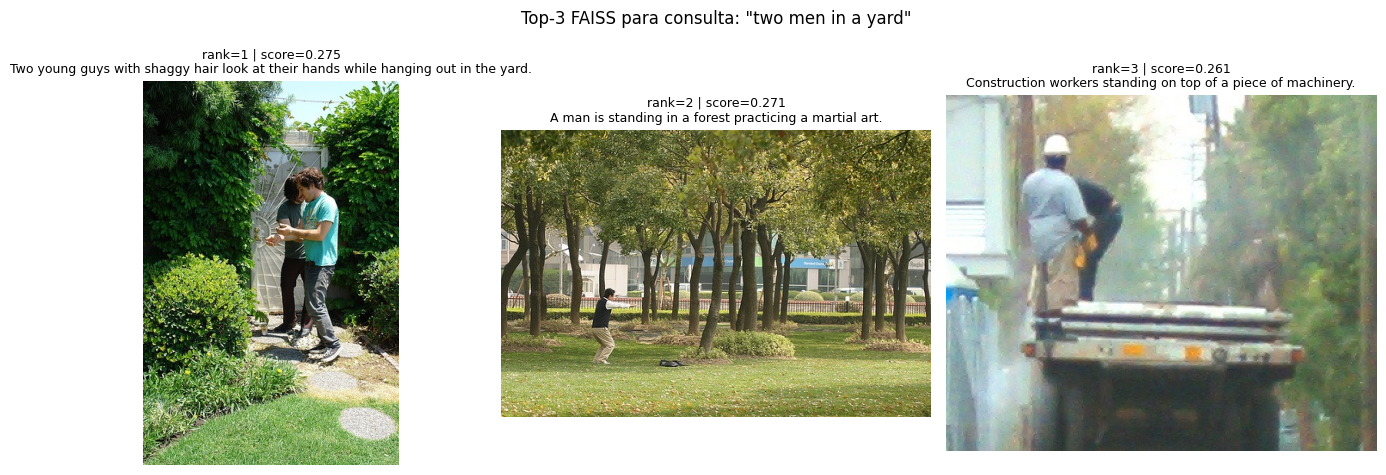

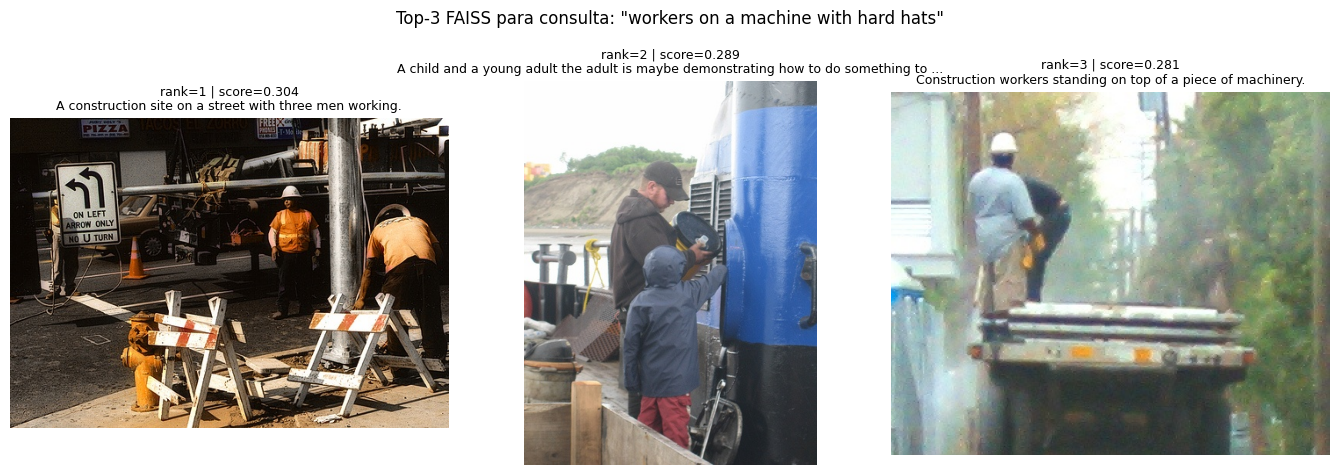

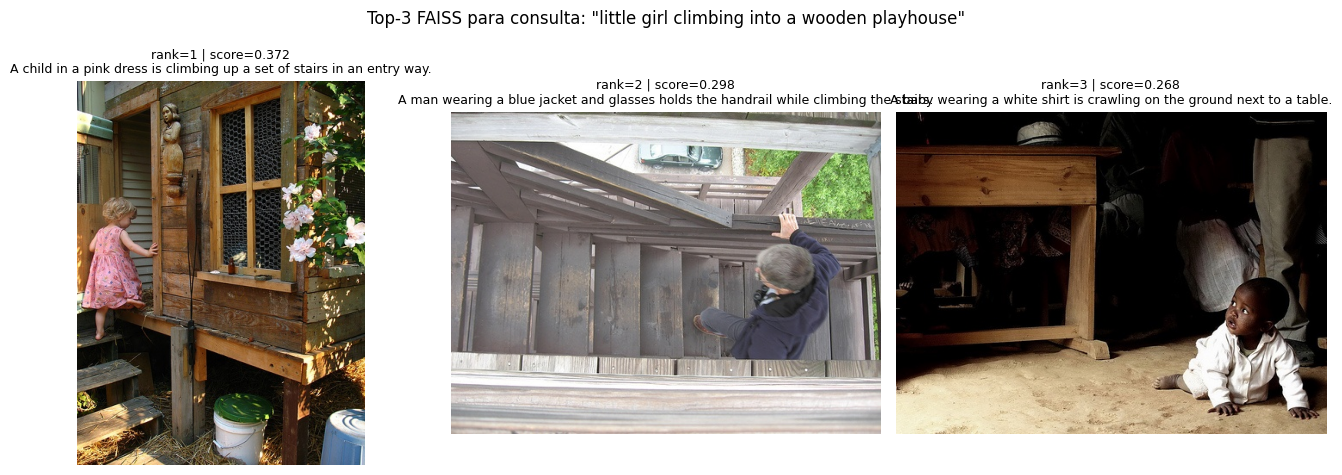

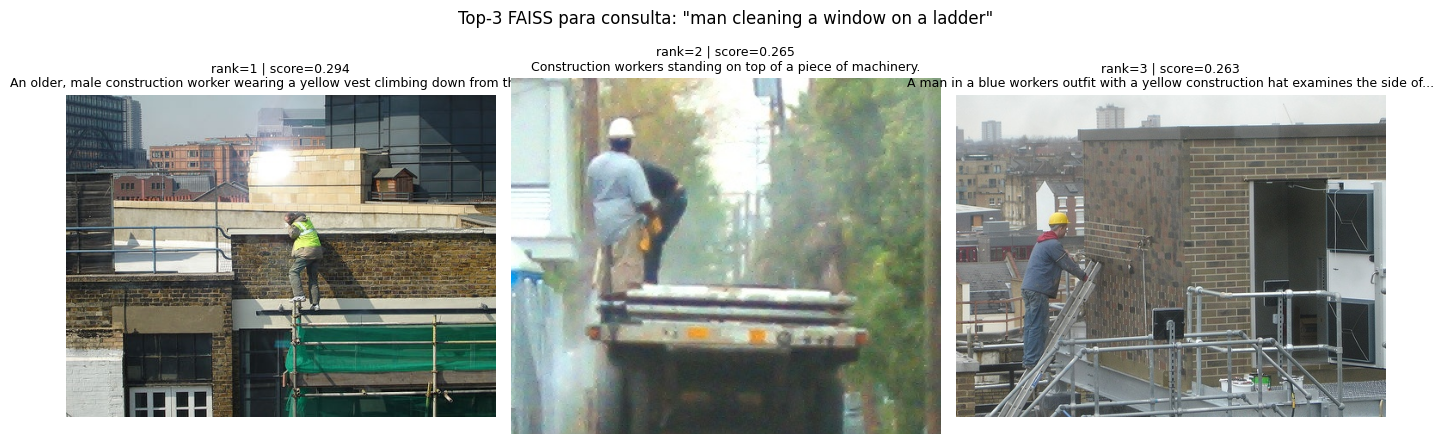

In [15]:
faiss_csv = PROJECT_ROOT / 'outputs' / 'faiss' / f'query_results_{dataset_id}.csv'
faiss_csv.parent.mkdir(parents=True, exist_ok=True)
queries_csv = PROJECT_ROOT / 'data' / 'bootstrap_flickr30k' / 'queries.csv'

if queries_csv.exists():
    if not faiss_csv.exists():
        faiss_cmd = [
            sys.executable,
            str(PROJECT_ROOT / 'scripts' / '06_build_faiss_index.py'),
            '--embeddings', str(emb_path),
            '--metadata-csv', str(metadata_csv),
            '--queries-csv', str(queries_csv),
            '--output-csv', str(faiss_csv),
        ]
        print('Ejecutando búsqueda FAISS:')
        print(' '.join(faiss_cmd))
        subprocess.run(faiss_cmd, cwd=PROJECT_ROOT, check=True)

    # keep_default_na=False + sanitize_dataframe_values evita que valores vacíos aparezcan como texto no deseado.
    faiss_results_df = sanitize_dataframe_values(pd.read_csv(faiss_csv, keep_default_na=False))

    faiss_display_columns = [
        'query',
        'rank',
        'image_id',
        'filepath',
        'label',
        'caption',
        'score',
    ]
    display_clean_dataframe(
        faiss_results_df,
        columns=faiss_display_columns,
        n=12,
        hide_empty_label=True,
    )

    def plot_faiss_topk_retrieval(results_df, query=None, k=3):
        """Visualiza resultados FAISS top-k sin valores vacíos en títulos, etiquetas o captions."""
        if results_df is None or len(results_df) == 0:
            display(Markdown('No hay resultados FAISS disponibles para visualizar.'))
            return

        df = sanitize_dataframe_values(results_df)
        if 'query' not in df.columns:
            display(Markdown('El archivo FAISS no contiene columna `query`.'))
            return

        df['query_clean'] = df['query'].apply(lambda x: clean_text(x, fallback=''))
        available_queries = [q for q in df['query_clean'].unique() if q]

        if not available_queries:
            display(Markdown('No hay consultas no vacías para visualizar.'))
            return

        safe_query = clean_text(query, fallback=available_queries[0])
        sub = (
            df[df['query_clean'] == safe_query]
            .assign(rank_num=lambda x: pd.to_numeric(x.get('rank'), errors='coerce'))
            .sort_values('rank_num')
            .head(k)
            .reset_index(drop=True)
        )

        if sub.empty:
            display(Markdown(f'No hay resultados para la consulta: `{safe_query}`.'))
            return

        fig, axes = plt.subplots(1, len(sub), figsize=(4.5 * len(sub), 4.8))
        if len(sub) == 1:
            axes = [axes]

        for ax, (_, row) in zip(axes, sub.iterrows()):
            try:
                image_path = resolve_project_path(row.get('filepath', ''))
                image = Image.open(image_path).convert('RGB')
                ax.imshow(image)
            except Exception as exc:
                ax.text(
                    0.5,
                    0.5,
                    f"No se pudo cargar la imagen\n{type(exc).__name__}",
                    ha="center",
                    va="center",
                )

            rank = clean_text(row.get('rank', ''), fallback='?')
            caption = shorten_text(row.get('caption', ''), max_chars=85, fallback='sin caption')

            try:
                score_text = f"{float(row.get('score', 0.0)):.3f}"
            except Exception:
                score_text = clean_text(row.get('score', ''), fallback='sin score')

            # La etiqueta se omite en el título si no es una etiqueta cerrada real.
            ax.set_title(
                f"rank={rank} | score={score_text}\n{caption}",
                fontsize=9,
            )
            ax.axis('off')

        fig.suptitle(f'Top-{len(sub)} FAISS para consulta: "{safe_query}"', fontsize=12)
        plt.tight_layout()
        plt.show()

    for query in [q for q in faiss_results_df['query'].apply(lambda x: clean_text(x, fallback='')).unique() if q][:4]:
        plot_faiss_topk_retrieval(faiss_results_df, query=query, k=3)

else:
    faiss_results_df = pd.DataFrame()
    display(Markdown('No se encontró `queries.csv`, se omite la extensión FAISS.'))


#### **Interpretación de la búsqueda FAISS**

La búsqueda FAISS evalúa recuperación semántica texto-imagen usando los embeddings generados por el modelo contrastivo. 
En el subconjunto ampliado Flickr1k no se dispone de etiquetas cerradas de clase, por lo que la columna `label`, si aparece, 
puede estar vacía. Esto no afecta la validez funcional de la recuperación, ya que el ranking se calcula por similitud entre 
el embedding de la consulta textual y los embeddings de las imágenes.

Los resultados deben analizarse cualitativamente observando si las imágenes recuperadas y sus captions son semánticamente 
compatibles con la consulta. El valor `score` permite comparar la cercanía relativa dentro de una misma consulta, pero no debe 
interpretarse como probabilidad.


#### **7. Pruebas simples para `src/metrics.py`**

Se agregan pruebas unitarias mínimas para similitud, ranking multióbjetivo y matriz de confusión. No sustituyen una suite completa, pero sí detectan errores básicos que invalidarían la evaluación experimental.


In [16]:
test_metrics_py = PATHS['tests'] / 'test_metrics.py'
test_lines = [
    'import numpy as np',
    '',
    'from src.metrics import compute_similarity_matrix, summarize_multi_target_ranking, confusion_from_predictions',
    '',
    'def test_compute_similarity_matrix_shape_and_values():',
    '    a = np.array([[1.0, 0.0], [0.0, 1.0]], dtype=np.float32)',
    '    b = np.array([[1.0, 0.0], [1.0, 1.0]], dtype=np.float32)',
    '    sim = compute_similarity_matrix(a, b)',
    '    assert sim.shape == (2, 2)',
    '    assert np.allclose(sim, np.array([[1.0, 1.0], [0.0, 1.0]], dtype=np.float32))',
    '',
    'def test_summarize_multi_target_ranking_perfect_recall():',
    '    sim = np.array([[0.9, 0.1, 0.2], [0.1, 0.8, 0.2], [0.1, 0.2, 0.7]], dtype=np.float32)',
    '    positives = {0: [0], 1: [1], 2: [2]}',
    '    metrics = summarize_multi_target_ranking(sim, positives)',
    '    assert metrics["R@1"] == 1.0',
    '    assert metrics["MRR"] == 1.0',
    '    assert metrics["MedianRank"] == 1.0',
    '',
    'def test_summarize_multi_target_ranking_multiple_positives():',
    '    sim = np.array([[0.2, 0.8, 0.7]], dtype=np.float32)',
    '    positives = {0: [0, 2]}',
    '    metrics = summarize_multi_target_ranking(sim, positives)',
    '    assert metrics["Ranks"] == [2]',
    '    assert metrics["R@1"] == 0.0',
    '    assert metrics["R@5"] == 1.0',
    '',
    'def test_confusion_from_predictions_counts():',
    '    conf = confusion_from_predictions(["cat", "cat", "dog"], ["cat", "dog", "dog"])',
    '    assert conf.loc["cat", "cat"] == 1',
    '    assert conf.loc["cat", "dog"] == 1',
    '    assert conf.loc["dog", "dog"] == 1',
]
test_metrics_py.write_text('\n'.join(test_lines) + '\n', encoding='utf-8')

from src.metrics import confusion_from_predictions

a = np.array([[1.0, 0.0], [0.0, 1.0]], dtype=np.float32)
b = np.array([[1.0, 0.0], [1.0, 1.0]], dtype=np.float32)
assert compute_similarity_matrix(a, b).shape == (2, 2)
metrics_test = summarize_multi_target_ranking(np.array([[0.2, 0.8, 0.7]], dtype=np.float32), {0: [0, 2]})
assert metrics_test['Ranks'] == [2]
assert metrics_test['R@5'] == 1.0
conf_test = confusion_from_predictions(['cat', 'cat', 'dog'], ['cat', 'dog', 'dog'])
assert int(conf_test.loc['cat', 'dog']) == 1

print(f'Pruebas mínimas superadas. Archivo creado: {test_metrics_py.relative_to(PROJECT_ROOT)}')
print('Si pytest está disponible: python -m pytest tests/test_metrics.py')


Pruebas mínimas superadas. Archivo creado: tests/test_metrics.py
Si pytest está disponible: python -m pytest tests/test_metrics.py


#### **8. Reporte interpretativo**

Se presenta un reporte que indica el modelo, *checkpoint*, escala del subconjunto, métricas, errores, costo, limitaciones.


In [17]:
def dataframe_to_markdown(df, index=False):
    """Convierte tablas a Markdown limpiando valores vacíos para evitar NaN visuales."""
    if df is None or len(df) == 0:
        return '_Sin datos disponibles._'
    clean_df = clean_dataframe_for_display(df, hide_empty_label=True)
    try:
        return clean_df.to_markdown(index=index)
    except Exception:
        return '```csv\n' + clean_df.to_csv(index=index) + '\n```'


def build_interpretive_report():
    retrieval_md = dataframe_to_markdown(retrieval_metrics_df)
    zs_md = dataframe_to_markdown(zs_summary_df)
    ckpt_md = dataframe_to_markdown(checkpoint_comparison_df)
    cost_md = dataframe_to_markdown(checkpoint_cost_df)
    retrieval_interpretation = '\n'.join(
        f'- {interpret_retrieval(row, len(metadata) if row["direction"] == "image_to_text" else len(caption_df))}'
        for _, row in retrieval_metrics_df.iterrows()
    )

    if len(metadata) >= 100:
        dataset_validity = (
            f'El subconjunto contiene {len(metadata)} imágenes y {len(caption_df)} captions; '
            'supera el umbral mínimo de 100 imágenes, aunque sigue siendo una muestra acotada.'
        )
    else:
        dataset_validity = (
            f'El subconjunto contiene solo {len(metadata)} imágenes, sirve para validar el flujo, '
            'pero no para conclusiones cuantitativas generales.'
        )

    zero_shot_note = (
        'La evaluación zero-shot se considera principal porque el dataset activo contiene etiquetas cerradas.'
        if zeroshot_mode == 'evaluacion_etiquetada_principal'
        else 'La evaluación zero-shot se considera demostrativa porque el subconjunto ampliado no contiene etiquetas cerradas compatibles.'
    )

    report_parts = [
        '### Reporte interpretativo-Semana 5 MCC225',
        '',
        '#### 1. Configuración experimental',
        f'- Dataset activo: `{dataset_id}`.',
        f'- Modo de dataset: `{dataset_mode}`.',
        f'- Imágenes evaluadas: `{len(metadata)}`.',
        f'- Captions evaluadas: `{len(caption_df)}`.',
        f'- Modelo base: `{MODEL_NAME}`.',
        f'- Checkpoint base: `{PRETRAINED}`.',
        f'- Batch size: `{BATCH_SIZE}`.',
        f'- GPU: `{clean_text(environment_record.get("gpu_name"), fallback="no_disponible")}`.',
        f'- CUDA disponible: `{environment_record.get("cuda_available")}`.',
        '- Registro de entorno: `outputs/metadata/environment_record.json`.',
        '',
        '#### 2. Validez del subconjunto',
        dataset_validity,
        '',
        '#### 3. Métricas de recuperación',
        retrieval_md,
        '',
        '##### Interpretación',
        retrieval_interpretation,
        '',
        'La lectura de `R@1` debe complementarse con `MRR` y con inspección cualitativa de resultados top-k. Un resultado alto en un subconjunto pequeño puede deberse a baja ambigüedad semántica, por ello se exige análisis de errores.',
        '',
        '#### 4. Evaluación zero-shot',
        f'Modo: `{zeroshot_mode}`.',
        '',
        zero_shot_note,
        '',
        zs_md,
        '',
        f'La matriz de confusión se guardó en `outputs/figures/zeroshot_confusion_{zeroshot_mode}.png`.',
        '',
        '#### 5. Comparación de checkpoints',
        ckpt_md,
        '',
        '#### 6. Costo computacional por checkpoint',
        cost_md,
        '',
        'Cuando el costo no se haya medido, el estudiante debe declararlo y no recomendar despliegue solo por accuracy o recall.',
        '',
        '#### 7. Limitaciones',
        '1. Flickr30k está orientado a recuperación imagen-texto, no toda evaluación zero-shot sobre este corpus es naturalmente cerrada.',
        '2. Las métricas dependen del tamaño y diversidad del subconjunto.',
        '3. Las captions múltiples mejoran la evaluación imagen->texto, pero también pueden introducir ambigüedad semántica.',
        '4. Los resultados con OpenCLIP pueden variar por checkpoint, hardware y versión de librerías.',
        '5. El fine-tuning debe tratarse como demostración operativa salvo que incluya diseño experimental completo.',
        '']
    return '\n'.join(report_parts)


report_text = build_interpretive_report()
report_path = PATHS['reports'] / 'semana5_resultados_interpretado.md'
report_path.write_text(report_text, encoding='utf-8')
display(Markdown(report_text[:4000] + ('\n\n_Reporte truncado en vista del cuaderno. RevisA el archivo completo._' if len(report_text) > 4000 else '')))
print(f'Reporte guardado en: {report_path.relative_to(PROJECT_ROOT)}')


### Reporte interpretativo-Semana 5 MCC225

#### 1. Configuración experimental
- Dataset activo: `flickr1k_eval_300`.
- Modo de dataset: `expanded_retrieval_parquet_flickr1k`.
- Imágenes evaluadas: `300`.
- Captions evaluadas: `1500`.
- Modelo base: `ViT-B-32`.
- Checkpoint base: `laion2b_s34b_b79k`.
- Batch size: `32`.
- GPU: `no_disponible`.
- CUDA disponible: `False`.
- Registro de entorno: `outputs/metadata/environment_record.json`.

#### 2. Validez del subconjunto
El subconjunto contiene 300 imágenes y 1500 captions; supera el umbral mínimo de 100 imágenes, aunque sigue siendo una muestra acotada.

#### 3. Métricas de recuperación
| direction     |      R@1 |   R@5 |     R@10 |      MRR |   MeanRank |   MedianRank |
|:--------------|---------:|------:|---------:|---------:|-----------:|-------------:|
| image_to_text | 0.903333 | 0.98  | 0.99     | 0.939224 |      1.54  |            1 |
| text_to_image | 0.790667 | 0.952 | 0.971333 | 0.860961 |      2.234 |            1 |

##### Interpretación
- En image_to_text, R@1=0.903 y MRR=0.939, desempeño muy alto para 300 consultas evaluadas.
- En text_to_image, R@1=0.791 y MRR=0.861, desempeño moderado-alto para 1500 consultas evaluadas.

La lectura de `R@1` debe complementarse con `MRR` y con inspección cualitativa de resultados top-k. Un resultado alto en un subconjunto pequeño puede deberse a baja ambigüedad semántica, por ello se exige análisis de errores.

#### 4. Evaluación zero-shot
Modo: `demostracion_bootstrap`.

La evaluación zero-shot se considera demostrativa porque el subconjunto ampliado no contiene etiquetas cerradas compatibles.

| mode            | template                                          |   accuracy |   accuracy_pct |
|:----------------|:--------------------------------------------------|-----------:|---------------:|
| prompt_ensemble | a photo of {}; an image of {}; a caption about {} |   0.833333 |          83.33 |
| single_template | a photo of {}                                     |   0.833333 |          83.33 |
| single_template | an image of {}                                    |   0.833333 |          83.33 |
| single_template | a caption about {}                                |   0.833333 |          83.33 |

La matriz de confusión se guardó en `outputs/figures/zeroshot_confusion_demostracion_bootstrap.png`.

#### 5. Comparación de checkpoints
| tag              | model_name   | pretrained            |   i2t_R@1 |   i2t_MRR |   t2i_R@1 |   t2i_MRR |   zeroshot_ensemble_acc | status   |
|:-----------------|:-------------|:----------------------|----------:|----------:|----------:|----------:|------------------------:|:---------|
| vit_b32_laion2b  | ViT-B-32     | laion2b_s34b_b79k     |  0.903333 |  0.939224 |  0.790667 |  0.860961 |                       0 | ok       |
| vit_b16_datacomp | ViT-B-16     | datacomp_xl_s13b_b90k |  0.92     |  0.952143 |  0.802667 |  0.870873 |                       0 | ok       |
| vit_l14_openai   | ViT-L-14     | openai                |  0.903333 |  0.944756 |  0.764667 |  0.844261 |                       0 | ok       |

#### 6. Costo computacional por checkpoint
| nota                                                                                                         |   n_images |   n_captions | gpu_name      | cuda_available   |
|:-------------------------------------------------------------------------------------------------------------|-----------:|-------------:|:--------------|:-----------------|
| Costo no medido en esta ejecución. Cambie MEASURE_CHECKPOINT_COST=True para registrar tiempo por checkpoint. |        300 |         1500 | no_disponible | False            |

Cuando el costo no se haya medido, el estudiante debe declararlo y no recomendar despliegue solo por accuracy o recall.

#### 7. Limitaciones
1. Flickr30k está orientado a recuperación imagen-texto, no toda evaluación zero-shot sobre este corpus es naturalmente cerrada.
2. Las métricas dependen del tamaño y diversidad del subconju

_Reporte truncado en vista del cuaderno. RevisA el archivo completo._

Reporte guardado en: reports/semana5_resultados_interpretado.md


#### **9. Ejercicios y extensiones opcionales**

Esta sección consolida las actividades que el estudiante debe completar para demostrar dominio metodológico del flujo de evaluación multimodal. La intención no es únicamente ejecutar código, sino justificar decisiones, interpretar resultados y reconocer las limitaciones experimentales del sistema evaluado.

**9.1 Ejercicios obligatorios**

1. Preparar o justificar un subconjunto de evaluación de entre 100 y 500 imágenes.  
   Si no es posible construir el subconjunto ampliado, debe explicarse la causa y declarar los resultados como verificación funcional.
2. Registrar el entorno de ejecución, incluyendo fecha, dispositivo, GPU disponible, CUDA, versión de PyTorch, versión de OpenCLIP, modelo y checkpoint utilizado.
3. Construir embeddings reproducibles para imágenes y textos, verificando la correspondencia entre metadata, captions y archivos generados.
4. Evaluar recuperación imagen->texto y texto->imagen usando métricas de ranking apropiadas, tales como Recall@K, MRR o métricas equivalentes.
5. Visualizar resultados top-k y discutir cualitativamente aciertos, errores parciales y recuperaciones semánticamente ambiguas.
6. Evaluar clasificación zero-shot únicamente cuando existan etiquetas cerradas compatibles con las clases definidas.  
   Si el subconjunto ampliado no contiene etiquetas compatibles, la evaluación zero-shot debe reportarse como demostración  y no como evidencia experimental concluyente.
7. Presentar una matriz de confusión para la evaluación zero-shot cuando corresponda, acompañada de una interpretación crítica.
8. Comparar al menos dos checkpoints o configuraciones del modelo cuando el entorno computacional lo permita.
9. Documentar el costo computacional aproximado por checkpoint, incluyendo tiempo de ejecución, dispositivo utilizado y tamaño de los embeddings generados.
10. Ejecutar pruebas mínimas de `src/metrics.py` para verificar la corrección de las métricas implementadas.
11. Entregar un reporte interpretativo que incluya resultados, análisis de error, limitaciones, decisiones metodológicas y recomendaciones de mejora.

**9.2 Extensiones opcionales**

Las siguientes actividades son extensiones recomendadas para estudiantes o grupos que dispongan de mayor tiempo o capacidad computacional:

1. Construir un índice FAISS para búsqueda eficiente sobre embeddings de imagen.
2. Medir de forma exhaustiva el costo computacional por checkpoint, incluyendo tiempo de carga del modelo, tiempo de inferencia, uso de memoria y tamaño de archivos resultantes.
3. Ejecutar el pipeline en un entorno distribuido o institucional, por ejemplo mediante `torchrun`, SLURM u otro sistema de planificación de trabajos.
4. Incorporar nuevas consultas textuales y analizar si el sistema recupera imágenes semánticamente pertinentes.
5. Ampliar el subconjunto de evaluación, manteniendo trazabilidad sobre la fuente, el criterio de selección y las limitaciones del muestreo.
6. Realizar un fine-tuning corto de OpenCLIP como demostración operativa.

El fine-tuning debe tratarse como una demostración técnica del procedimiento y no como evidencia concluyente de mejora, salvo que se cumplan condiciones experimentales mínimas: separación clara entre entrenamiento, validación y prueba, control de semillas, comparación con una línea base sin ajuste, análisis de sobreajuste y evaluación sobre datos no vistos.


In [18]:
RUN_DEMONSTRATIVE_FINETUNING = False

if RUN_DEMONSTRATIVE_FINETUNING:
    display(Markdown('**Fine-tuning demostrativo activado.** Verifique GPU, memoria, CSV de entrenamiento y diseño experimental. Los resultados no deben interpretarse como concluyentes sin evaluación rigurosa.'))
    # Ejemplo local. Ajuste según el README y los recursos disponibles.
    # subprocess.run(['bash', 'scripts/90_openclip_finetune_csv_local.sh'], cwd=PROJECT_ROOT, check=True)
else:
    display(Markdown('**Fine-tuning desactivado.** Se documenta como extensión opcional y demostrativa, no como parte obligatoria ni como evidencia concluyente de mejora.'))


**Fine-tuning desactivado.** Se documenta como extensión opcional y demostrativa, no como parte obligatoria ni como evidencia concluyente de mejora.